**1-Data Loading & Cleaning**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("PJME_hourly.csv")

In [3]:
dataset.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [4]:
dataset.shape

(145366, 2)

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 4.9 MB


In [6]:
dataset.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [7]:
dataset.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

In [8]:
dataset.duplicated().sum()

np.int64(0)

In [9]:
dataset["Datetime"] = pd.to_datetime(dataset["Datetime"])

In [10]:
dataset.dtypes

Datetime    datetime64[us]
PJME_MW            float64
dtype: object

In [11]:
dataset.columns

Index(['Datetime', 'PJME_MW'], dtype='str')

In [12]:
dataset = dataset.sort_values("Datetime")

In [13]:
dataset.head()

,Datetime,PJME_MW
8734,2002-01-01 01:00:00,30393.0
8735,2002-01-01 02:00:00,29265.0
8736,2002-01-01 03:00:00,28357.0
8737,2002-01-01 04:00:00,27899.0
8738,2002-01-01 05:00:00,28057.0


In [14]:
dataset.tail()

,Datetime,PJME_MW
140250,2018-08-02 20:00:00,44057.0
140251,2018-08-02 21:00:00,43256.0
140252,2018-08-02 22:00:00,41552.0
140253,2018-08-02 23:00:00,38500.0
140254,2018-08-03 00:00:00,35486.0


In [15]:
dataset.index

Index([  8734,   8735,   8736,   8737,   8738,   8739,   8740,   8741,   8742,
         8743,
       ...
       140245, 140246, 140247, 140248, 140249, 140250, 140251, 140252, 140253,
       140254],
      dtype='int64', length=145366)

In [16]:
dataset.columns

Index(['Datetime', 'PJME_MW'], dtype='str')

In [17]:
dataset = dataset.set_index("Datetime")

In [18]:
dataset.columns

Index(['PJME_MW'], dtype='str')

In [19]:
dataset.index

DatetimeIndex(['2002-01-01 01:00:00', '2002-01-01 02:00:00',
               '2002-01-01 03:00:00', '2002-01-01 04:00:00',
               '2002-01-01 05:00:00', '2002-01-01 06:00:00',
               '2002-01-01 07:00:00', '2002-01-01 08:00:00',
               '2002-01-01 09:00:00', '2002-01-01 10:00:00',
               ...
               '2018-08-02 15:00:00', '2018-08-02 16:00:00',
               '2018-08-02 17:00:00', '2018-08-02 18:00:00',
               '2018-08-02 19:00:00', '2018-08-02 20:00:00',
               '2018-08-02 21:00:00', '2018-08-02 22:00:00',
               '2018-08-02 23:00:00', '2018-08-03 00:00:00'],
              dtype='datetime64[us]', name='Datetime', length=145366, freq=None)

In [20]:
dataset.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [21]:
dataset.index.to_series().diff().value_counts().head()

Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64

In [22]:
time_diff = dataset.index.to_series().diff()

time_diff[time_diff != pd.Timedelta(hours=1)].head(50)

Datetime
2002-01-01 01:00:00               NaT
2002-04-07 04:00:00   0 days 02:00:00
2002-10-27 03:00:00   0 days 02:00:00
2003-04-06 04:00:00   0 days 02:00:00
2003-10-26 03:00:00   0 days 02:00:00
2004-04-04 04:00:00   0 days 02:00:00
2004-10-31 03:00:00   0 days 02:00:00
2005-04-03 04:00:00   0 days 02:00:00
2005-10-30 03:00:00   0 days 02:00:00
2006-04-02 04:00:00   0 days 02:00:00
2006-10-29 03:00:00   0 days 02:00:00
2007-03-11 04:00:00   0 days 02:00:00
2007-11-04 03:00:00   0 days 02:00:00
2008-03-09 04:00:00   0 days 02:00:00
2008-11-02 03:00:00   0 days 02:00:00
2009-03-08 04:00:00   0 days 02:00:00
2009-11-01 03:00:00   0 days 02:00:00
2010-03-14 04:00:00   0 days 02:00:00
2010-11-07 03:00:00   0 days 02:00:00
2010-12-10 01:00:00   0 days 02:00:00
2011-03-13 04:00:00   0 days 02:00:00
2011-11-06 03:00:00   0 days 02:00:00
2012-03-11 04:00:00   0 days 02:00:00
2012-11-04 03:00:00   0 days 02:00:00
2013-03-10 04:00:00   0 days 02:00:00
2013-11-03 03:00:00   0 days 02:00:00
201

In [23]:
duplicates = dataset.index[dataset.index.duplicated(keep=False)]
duplicates

DatetimeIndex(['2014-11-02 02:00:00', '2014-11-02 02:00:00',
               '2015-11-01 02:00:00', '2015-11-01 02:00:00',
               '2016-11-06 02:00:00', '2016-11-06 02:00:00',
               '2017-11-05 02:00:00', '2017-11-05 02:00:00'],
              dtype='datetime64[us]', name='Datetime', freq=None)

In [24]:
dataset.loc["2010-12-10 00:00:00":"2010-12-10 03:00:00"]

,PJME_MW
Datetime,
2010-12-10 01:00:00,33163.0
2010-12-10 02:00:00,32323.0
2010-12-10 03:00:00,32016.0


**2-EDA and Visualization**

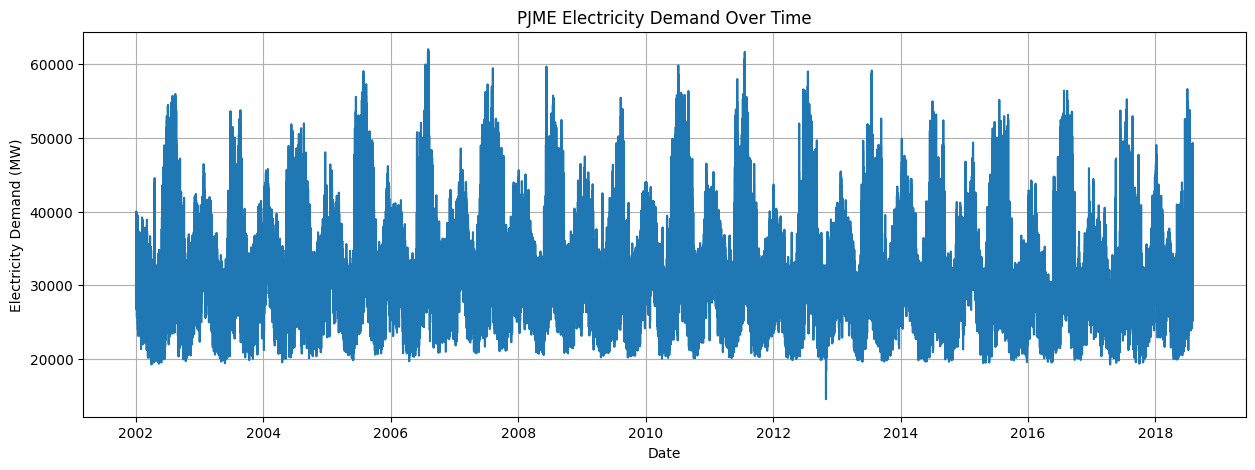

In [25]:
plt.figure(figsize=(15, 5))

plt.plot(dataset.index, dataset["PJME_MW"])

plt.title("PJME Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")
plt.grid(True)

plt.show()

The PJME electricity demand shows strong recurring patterns and significant variations over time.
The dataset contains low-demand periods, normal-demand periods, and several high peak-demand periods,
These patterns indicate the presence of seasonality and make the dataset suitable for electricity demand forecasting and peak-load prediction.

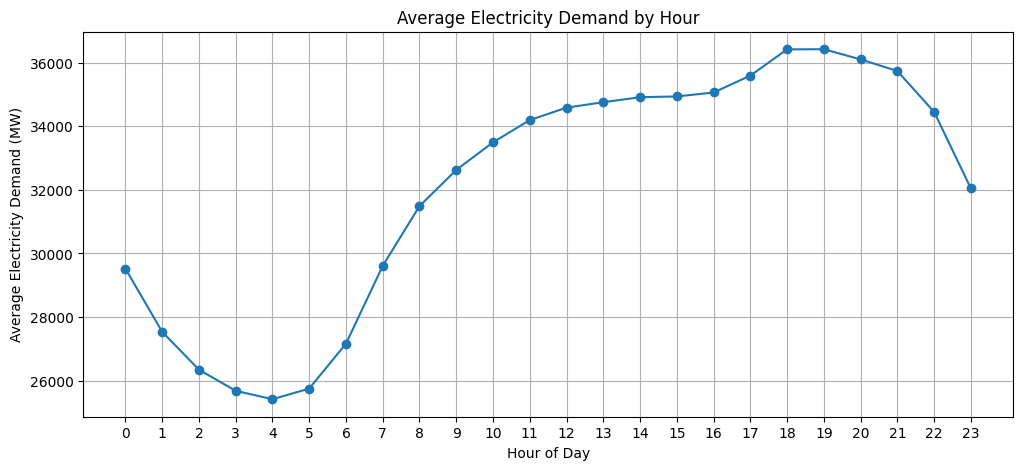

In [26]:
hourly_pattern = dataset.groupby(dataset.index.hour)["PJME_MW"].mean()

plt.figure(figsize=(12, 5))

plt.plot(hourly_pattern.index, hourly_pattern.values, marker="o")

plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Electricity Demand (MW)")
plt.xticks(range(24))
plt.grid(True)

plt.show()

The average hourly electricity demand shows a clear intraday seasonal pattern.
Demand is lowest during the early morning hours and gradually increases throughout the day.
The highest average demand occurs around 18:00–19:00, followed by a decline during the late evening hours.

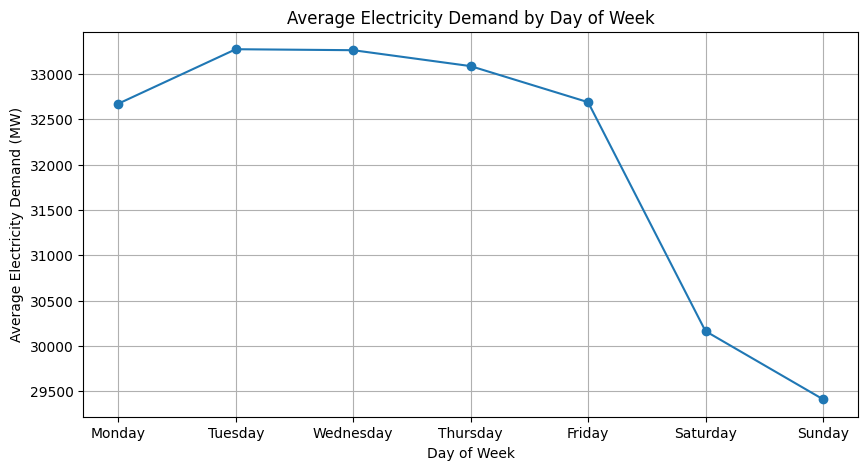

In [27]:
daily_pattern = dataset.groupby(dataset.index.dayofweek)["PJME_MW"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    daily_pattern.index,
    daily_pattern.values,
    marker="o"
)

plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Electricity Demand (MW)")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"]
)

plt.grid(True)

plt.show()

The average electricity demand shows a clear weekly seasonal pattern.
Demand remains relatively high during weekdays, with the highest levels observed around Tuesday and Wednesday.
Demand decreases significantly during the weekend, reaching its lowest level on Sunday. 
This indicates a weekly seasonality with an approximate period of 7 days.

In [28]:
monthly_pattern = dataset.groupby(dataset.index.month)["PJME_MW"].mean()

print(monthly_pattern)

Datetime
1     34343.246462
2     33434.972049
3     30514.903609
4     27863.339354
5     28695.362113
6     33811.799183
7     37881.972881
8     36595.959675
9     31484.054688
10    28119.228675
11    29328.733872
12    32676.247669
Name: PJME_MW, dtype: float64


The monthly average electricity demand shows noticeable seasonal variation.
July records the highest average demand at approximately 37,882 MW, followed by August at approximately 36,596 MW.
April records the lowest average demand at approximately 27,863 MW.
These variations suggest a possible relationship between electricity demand and seasonal factors.
Further analysis is required to confirm the recurring yearly pattern.

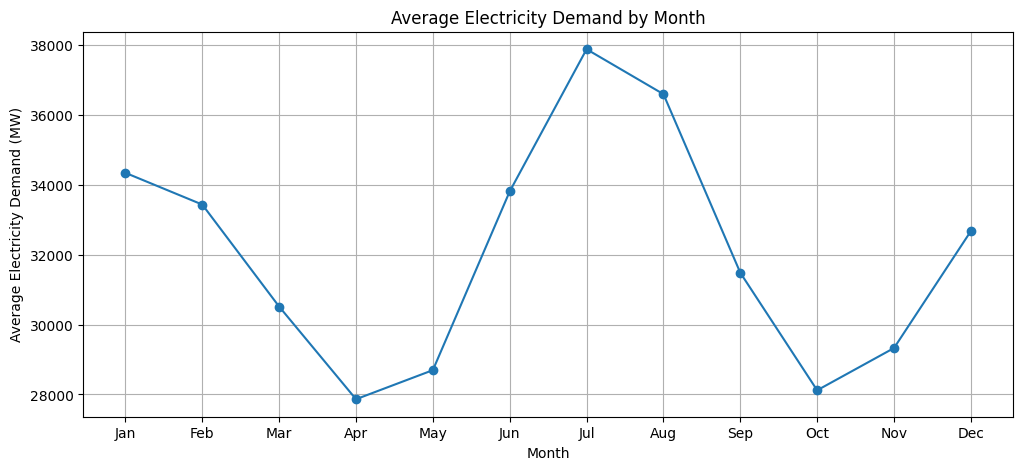

In [29]:
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Electricity Demand (MW)")
plt.xticks(range(1, 13), month_names)
plt.grid(True)

plt.show()

**Monthly Seasonality**
The monthly average electricity demand shows noticeable seasonal variation. July records the highest average demand at approximately 37,882 MW,
while April records the lowest at approximately 27,863 MW. January also shows relatively high demand, suggesting a possible secondary peak.
These observations indicate potential annual seasonality in electricity demand.
Further year-wise analysis is required to verify whether these patterns consistently repeat.

High demand = July (37,882 MW)

Low  demand = April (27,863 MW)

**Yearly Electricity Demand Analysis**

In [30]:
yearly_pattern = dataset.groupby(dataset.index.year)["PJME_MW"].mean()

print(yearly_pattern)

Datetime
2002    31565.617106
2003    31698.758621
2004    32270.434867
2005    33310.478648
2006    32409.269696
2007    33613.468600
2008    32929.593373
2009    31851.533683
2010    33101.172662
2011    32368.308518
2012    31440.107265
2013    31706.525120
2014    31496.406963
2015    31709.394178
2016    31337.833106
2017    30650.911644
2018    31782.598715
Name: PJME_MW, dtype: float64


**Yearly Electricity Demand**
The yearly average electricity demand fluctuates over the period from 2002 to 2018.The highest yearly average in the calculated results occurs in 2007 at approximately 33,613 MW,
while the lowest occurs in 2017 at approximately 30,651 MW. Demand does not increase or decrease consistently throughout the entire period,indicating noticeable year-to-year variations.
Further trend analysis is required to identify the long-term direction.


Highest yearly average — 2007
**33,613.47 MW**

Lowest yearly average — 2017
**30,650.91 MW**


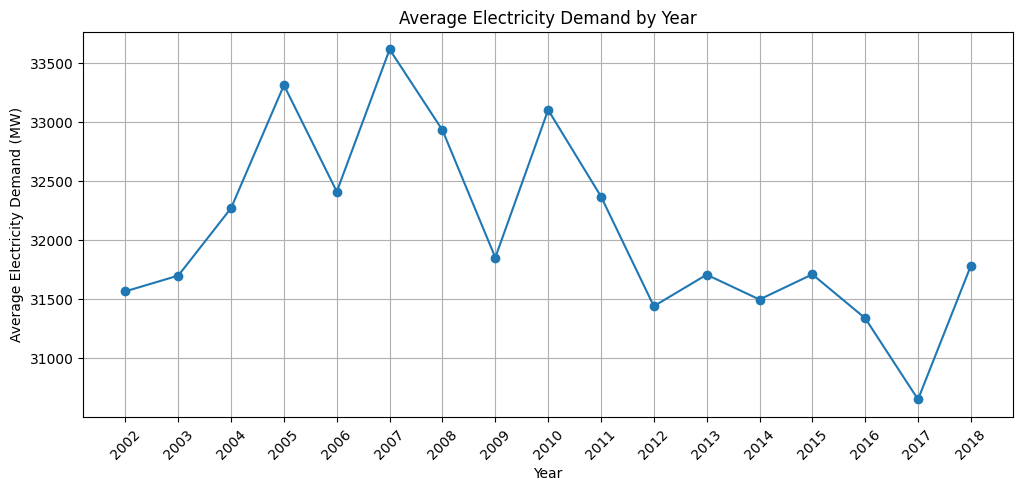

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    yearly_pattern.index,
    yearly_pattern.values,
    marker="o"
)

plt.title("Average Electricity Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Electricity Demand (MW)")
plt.xticks(yearly_pattern.index, rotation=45)
plt.grid(True)

plt.show()

**Yearly Trend Analysis**

The annual average electricity demand fluctuates between 2002 and 2018. Demand generally increases from 2002 to 2007,
decreases during 2008–2009, and partially recovers in 2010. A lower-demand period is observed during 2012–2017,
followed by an increase in 2018. These annual variations suggest possible long-term trend changes.
However, the causes of these changes cannot be confirmed from demand data alone.


**3-Time Series Analysis (TSA)**

**Rolling Mean & Rolling Standard Deviation**

In [32]:
dataset["Rolling_Mean_24H"] = dataset["PJME_MW"].rolling(window=24).mean()

dataset[["PJME_MW", "Rolling_Mean_24H"]].head(30)

,PJME_MW,Rolling_Mean_24H
Datetime,,
2002-01-01 01:00:00,30393.0,NaN
2002-01-01 02:00:00,29265.0,NaN
2002-01-01 03:00:00,28357.0,NaN
2002-01-01 04:00:00,27899.0,NaN
2002-01-01 05:00:00,28057.0,NaN
2002-01-01 06:00:00,28654.0,NaN
2002-01-01 07:00:00,29308.0,NaN
2002-01-01 08:00:00,29595.0,NaN
2002-01-01 09:00:00,29943.0,NaN


In [33]:

dataset["Rolling_Std_24H"] = dataset["PJME_MW"].rolling(window=24).std()

dataset[["PJME_MW", "Rolling_Mean_24H", "Rolling_Std_24H"]].head(30)

,PJME_MW,Rolling_Mean_24H,Rolling_Std_24H
Datetime,,,
2002-01-01 01:00:00,30393.0,NaN,NaN
2002-01-01 02:00:00,29265.0,NaN,NaN
2002-01-01 03:00:00,28357.0,NaN,NaN
2002-01-01 04:00:00,27899.0,NaN,NaN
2002-01-01 05:00:00,28057.0,NaN,NaN
2002-01-01 06:00:00,28654.0,NaN,NaN
2002-01-01 07:00:00,29308.0,NaN,NaN
2002-01-01 08:00:00,29595.0,NaN,NaN
2002-01-01 09:00:00,29943.0,NaN,NaN


**Column**-----                  **Value**  --------            **Meaning**

PJME_MW ---                    29,563 MW---            Actual electricity demand

Rolling_Mean_24H ---           31,017.50 MW --        Average of the 24 observations

Rolling_Std_24H --            2,423.67 MW--          Standard deviation of those observations

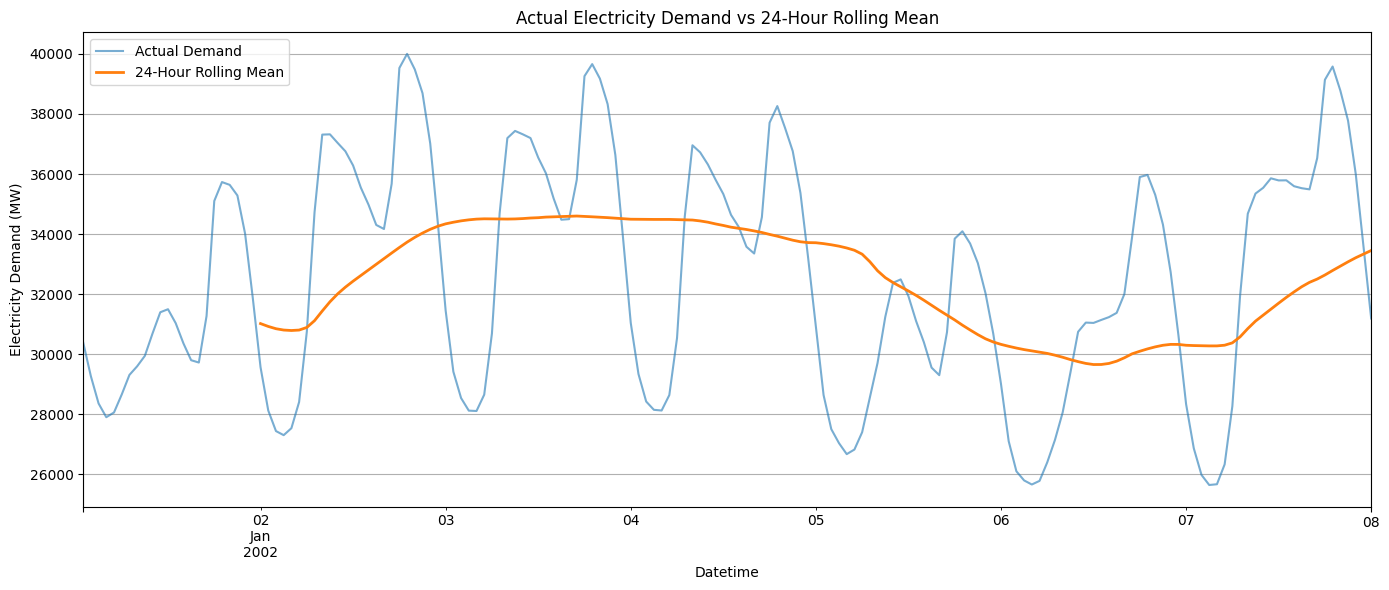

In [34]:
plt.figure(figsize=(14, 6))

dataset["PJME_MW"].iloc[:168].plot(label="Actual Demand", alpha=0.6)
dataset["Rolling_Mean_24H"].iloc[:168].plot(
    label="24-Hour Rolling Mean",
    linewidth=2
)

plt.title("Actual Electricity Demand vs 24-Hour Rolling Mean")
plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

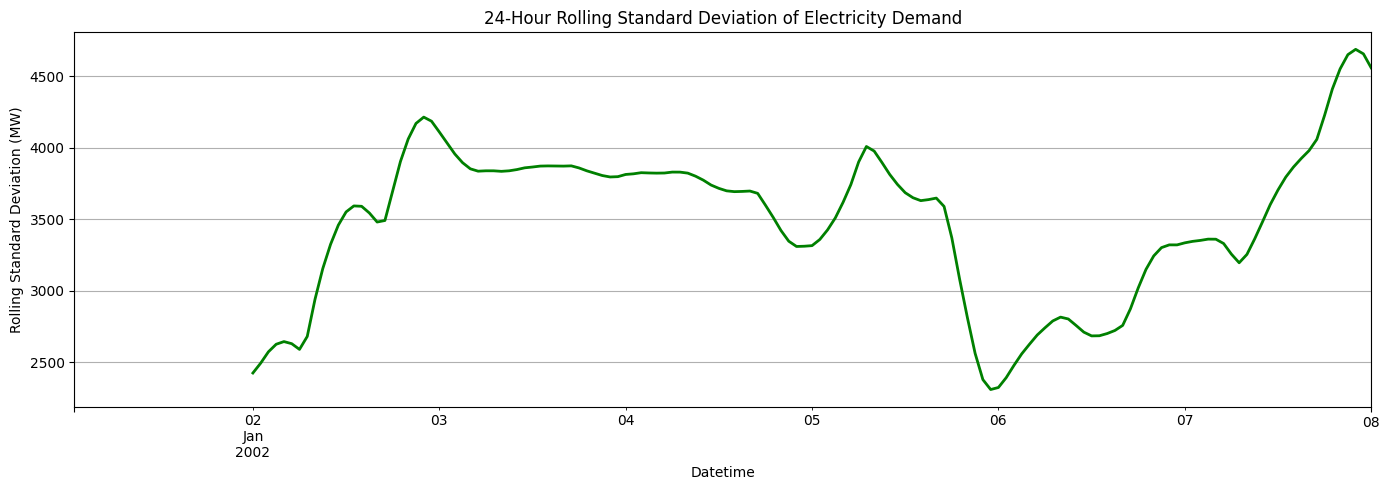

In [35]:
plt.figure(figsize=(14, 5))

dataset["Rolling_Std_24H"].iloc[:168].plot(
    color="green",
    linewidth=2
)

plt.title("24-Hour Rolling Standard Deviation of Electricity Demand")
plt.xlabel("Datetime")
plt.ylabel("Rolling Standard Deviation (MW)")
plt.grid(True)
plt.tight_layout()
plt.show()

**ADF Stationarity Test**

The Augmented Dickey–Fuller (ADF) test was applied to the hourly PJME electricity-demand dataset.

In [36]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(dataset["PJME_MW"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations:", adf_result[3])
print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -19.88134841399182
p-value: 0.0
Number of Lags Used: 75
Number of Observations: 145290

Critical Values:
1%: -3.4303950093987075
5%: -2.8615598935174043
10%: -2.566780588611286


Since the p-value is below 0.05 and the ADF statistic is below the 5% critical value,we reject the null hypothesis of a unit root.
The result provides strong evidence against a unit root in the original electricity-demand series.

However, this test alone does not establish that all aspects of the series are stationary.
Daily and weekly seasonality, changing variance, and other patterns should be investigated separately before selecting a forecasting model.

In [37]:
dataset["Demand_Diff_1"] = dataset["PJME_MW"].diff()

adf_diff_result = adfuller(dataset["Demand_Diff_1"].dropna())

print("ADF Statistic after First Differencing:", adf_diff_result[0])
print("P-value after First Differencing:", adf_diff_result[1])
print("5% Critical Value:", adf_diff_result[4]["5%"])

ADF Statistic after First Differencing: -54.37769029663102
P-value after First Differencing: 0.0
5% Critical Value: -2.8615598935174043


**ADF test comparison**

Metric------------------------------------Original series----------------------First difference

ADF Statistic--------------------------------19.8813------------------------------(-54.3777)

P-value---------------------------------------0.0--------------------------------(0.0)

5% Critical Value-----------------------------2.8616-----------------------------(-2.8616)

**Both tests reject the unit-root null hypothesis**

**Plot the first-differenced series**

Let's visually inspect how much electricity demand changes from one observation to the next.

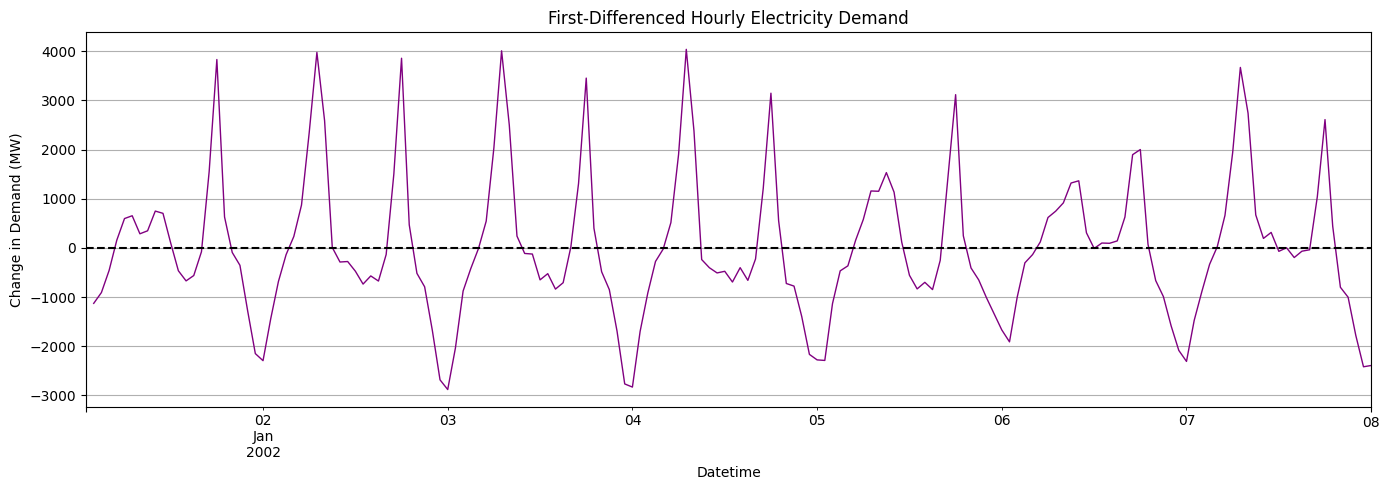

In [38]:
plt.figure(figsize=(14, 5))

dataset["Demand_Diff_1"].iloc[:168].plot(
    color="purple",
    linewidth=1
)

plt.axhline(y=0, color="black", linestyle="--")
plt.title("First-Differenced Hourly Electricity Demand")
plt.xlabel("Datetime")
plt.ylabel("Change in Demand (MW)")
plt.grid(True)
plt.tight_layout()
plt.show()

**4-ADF, ACF, PACF & Decomposition**

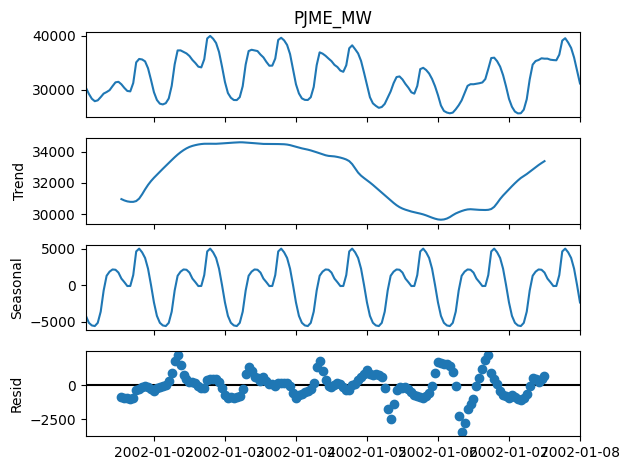

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose

sample = dataset["PJME_MW"].iloc[:24 * 7].copy()

decomposition = seasonal_decompose(
    sample,
    model="additive",
    period=24
)

decomposition.plot()
plt.tight_layout()
plt.show()

**Check the residuals**

In [40]:
residuals = decomposition.resid.dropna()

print("Residual count:", len(residuals))
print("Residual mean:", residuals.mean())
print("Residual standard deviation:", residuals.std())
print("Residual minimum:", residuals.min())
print("Residual maximum:", residuals.max())

Residual count: 144
Residual mean: -34.43258101851666
Residual standard deviation: 920.6200385200626
Residual minimum: -3464.6027199074024
Residual maximum: 2197.626446759257


**Residual count = 144**------ I started with 168 hourly observations (7 days).
Decomposition left 144 usable residuals because the trend filter creates missing values at the boundaries.

**Mean = −34.43 MW**----- The residual average is relatively close to zero.

**Standard deviation = 920.62 MW**------- The residuals have substantial remaining variation.

**Minimum and maximum**-------- Some observations differ considerably from the estimated trend-plus-seasonal components.


**Check residual autocorrelation**

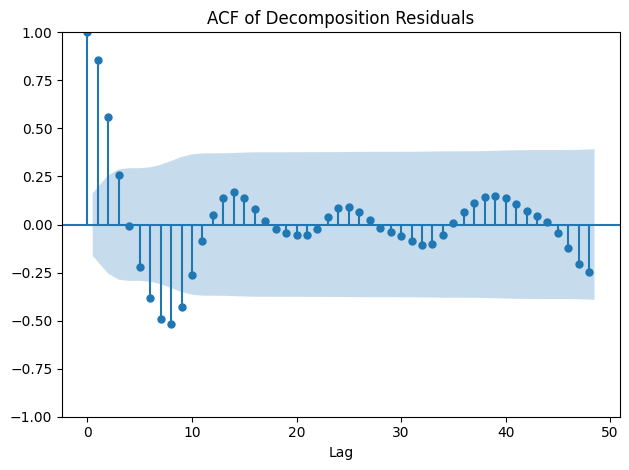

In [41]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=48)
plt.title("ACF of Decomposition Residuals")
plt.xlabel("Lag")
plt.tight_layout()
plt.show()

Lag 0 = 1.0------ Every series is perfectly correlated with itself at lag zero.  

Positive autocorrelation---- Residuals tend to move together across the specified lag.

Negative autocorrelation-------- Higher residuals tend to be associated with lower residuals at that lag.

Significant bars outside the confidence band----- Evidence that residual autocorrelation remains.

**Explore weekly seasonality with MSTL**

Daily: 24 observations

Weekly: 168 observations

In [42]:
import statsmodels
from statsmodels.tsa.seasonal import MSTL

print("Statsmodels version:", statsmodels.__version__)
print("MSTL is available.")

Statsmodels version: 0.14.6
MSTL is available.


**Prepare a longer sample**

Previously,I used only seven days. To study weekly seasonality more reliably, let's use eight weeks of hourly demand data.

In [44]:
# Select the first 8 weeks of hourly electricity demand
mstl_sample = dataset["PJME_MW"].iloc[:24 * 7 * 8].copy()

print("Number of observations:", len(mstl_sample))
print("Start date:", mstl_sample.index.min())
print("End date:", mstl_sample.index.max())
print("Missing values:", mstl_sample.isna().sum())

Number of observations: 1344
Start date: 2002-01-01 01:00:00
End date: 2002-02-26 00:00:00
Missing values: 0


**Apply MSTL decomposition**

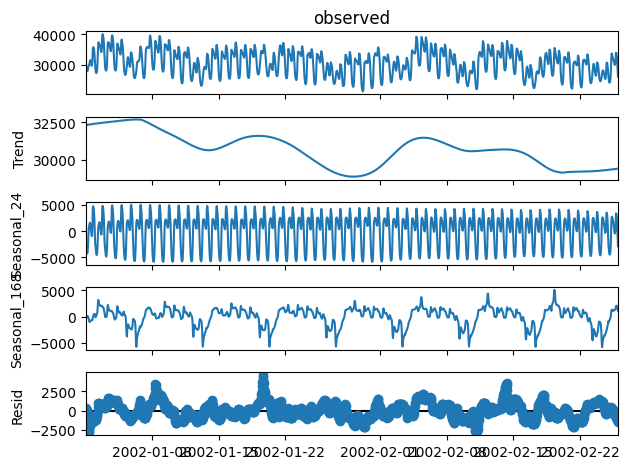

In [45]:
mstl_model = MSTL(
    mstl_sample,
    periods=(24, 168)
)

mstl_result = mstl_model.fit()

mstl_result.plot()
plt.tight_layout()
plt.show()

Multiple Seasonal-Trend decomposition using LOESS (MSTL).

Through MSTL, electricity demand is divided into four parts: Trend, Daily Seasonality, Weekly Seasonality, and Residual.

**Inspect the MSTL residuals**

In [47]:
mstl_residuals = mstl_result.resid.dropna()

print("Residual count:", len(mstl_residuals))
print("Residual mean:", mstl_residuals.mean())
print("Residual standard deviation:", mstl_residuals.std())
print("Residual minimum:", mstl_residuals.min())
print("Residual maximum:", mstl_residuals.max())

Residual count: 1344
Residual mean: 1.7539020042177775
Residual standard deviation: 1025.1462361824981
Residual minimum: -2830.4390019103193
Residual maximum: 4601.836548375883


**Check MSTL residual autocorrelation (ACF)**

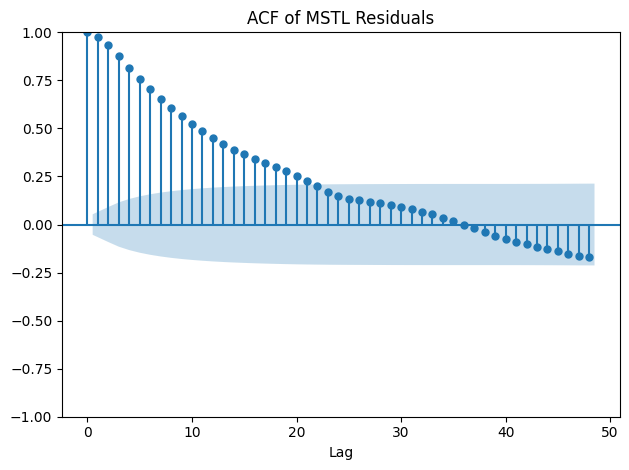

In [48]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(mstl_residuals, lags=48)

plt.title("ACF of MSTL Residuals")
plt.xlabel("Lag")
plt.tight_layout()
plt.show()

**Baseline Forecasting**

In [49]:
# Use the original electricity demand series
ts = dataset["PJME_MW"].copy()

# Chronological 80/20 split (no random shuffling)
split_index = int(len(ts) * 0.8)

train = ts.iloc[:split_index]
test = ts.iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())

Training observations: 116292
Testing observations: 29074
Training period: 2002-01-01 01:00:00 to 2015-04-09 14:00:00
Testing period: 2015-04-09 15:00:00 to 2018-08-03 00:00:00


Dataset------------------Observations-------------------Period

Training data------------116,292 (80%)-----------------Jan 2002 – Apr 2015

Testing data-------------29,074 (20%)------------------Apr 2015 – Aug 2018

**5-Naive, SES & Holt-Winters**

**Naive Forecasting**

In [50]:
# Naive forecast: use the previous observation's demand
naive_predictions = test.shift(1)

# For the first test observation, use the final training observation
naive_predictions.iloc[0] = train.iloc[-1]

print("Actual demand (first 5 test observations):")
print(test.head())

print("\nNaive forecast (first 5 test observations):")
print(naive_predictions.head())

Actual demand (first 5 test observations):
Datetime
2015-04-09 15:00:00    32204.0
2015-04-09 16:00:00    32049.0
2015-04-09 17:00:00    32209.0
2015-04-09 18:00:00    32707.0
2015-04-09 19:00:00    33012.0
Name: PJME_MW, dtype: float64

Naive forecast (first 5 test observations):
Datetime
2015-04-09 15:00:00    32613.0
2015-04-09 16:00:00    32204.0
2015-04-09 17:00:00    32049.0
2015-04-09 18:00:00    32209.0
2015-04-09 19:00:00    32707.0
Name: PJME_MW, dtype: float64


For the first test observation, the model uses the final training value, 32,613 MW. For subsequent observations, it uses the previous actual demand.

**Evaluate the model**

Now we'll calculate---- **MAE, RMSE, and MAPE**--- to understand how far the predictions are from actual electricity demand.

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Remove any missing prediction/actual pairs
valid = naive_predictions.notna() & test.notna()

actual = test.loc[valid]
predicted = naive_predictions.loc[valid]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

MAE:  1069.76 MW
RMSE: 1373.61 MW
MAPE: 3.48%


"When predicting the next electricity demand using the previous observation, the average percentage error was around 3.48%. This serves as our baseline result.
We need to build a better model to see if we can reduce this error further."

**Visualize actual vs predicted demand**

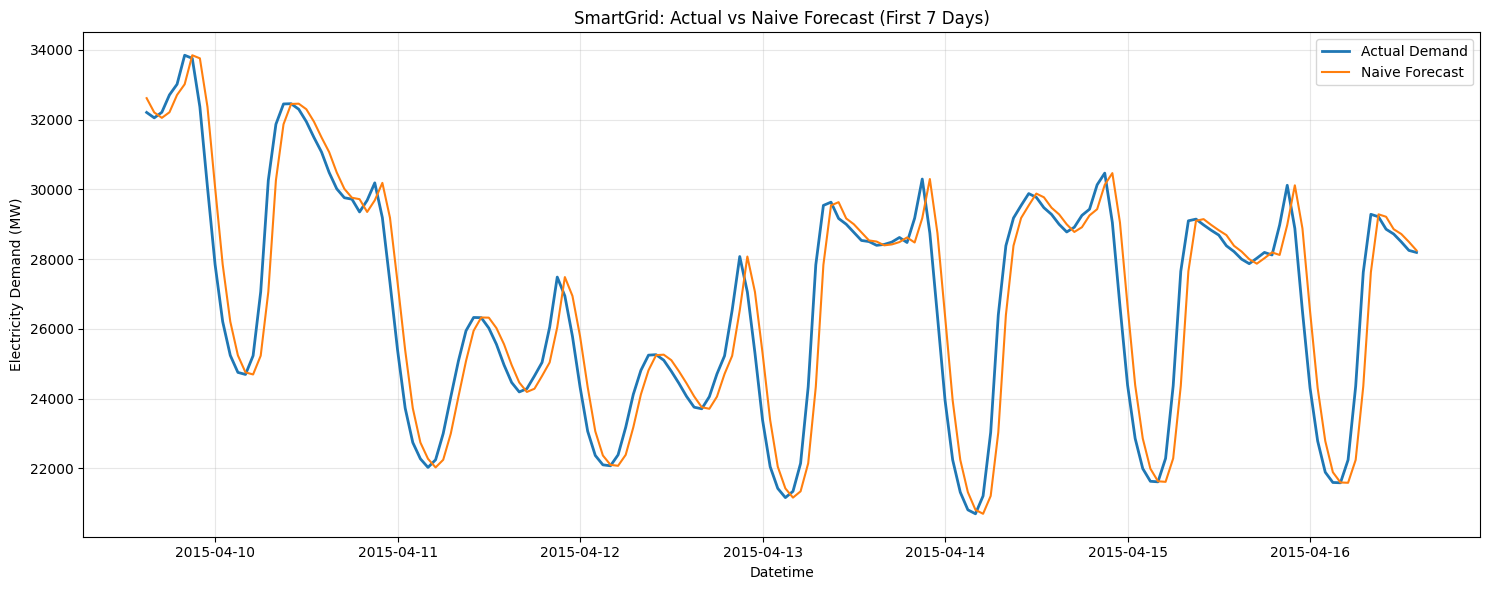

In [52]:
import matplotlib.pyplot as plt

# Display the first 7 days of test predictions
hours_to_plot = 24 * 7

plt.figure(figsize=(15, 6))

plt.plot(
    actual.index[:hours_to_plot],
    actual.iloc[:hours_to_plot],
    label="Actual Demand",
    linewidth=2
)

plt.plot(
    predicted.index[:hours_to_plot],
    predicted.iloc[:hours_to_plot],
    label="Naive Forecast",
    linewidth=1.5
)

plt.title("SmartGrid: Actual vs Naive Forecast (First 7 Days)")
plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Check Time Index Regularity and Data Quality**

In [53]:
# Check the time index for hourly regularity

time_diff = ts.index.to_series().diff()

print("Time interval counts:")
print(time_diff.value_counts().head(10))

print("\nDuplicate timestamps:", ts.index.duplicated().sum())
print("Missing demand values:", ts.isna().sum())
print("Chronologically sorted:", ts.index.is_monotonic_increasing)

Time interval counts:
Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64

Duplicate timestamps: 4
Missing demand values: 0
Chronologically sorted: True


**Inspect duplicate timestamps**

In [54]:
# Identify duplicate timestamps
duplicate_mask = ts.index.duplicated(keep=False)

duplicate_data = ts[duplicate_mask].sort_index()

print("Duplicate timestamp records:")
print(duplicate_data)

Duplicate timestamp records:
Datetime
2014-11-02 02:00:00    23755.0
2014-11-02 02:00:00    22935.0
2015-11-01 02:00:00    21567.0
2015-11-01 02:00:00    21171.0
2016-11-06 02:00:00    20795.0
2016-11-06 02:00:00    21692.0
2017-11-05 02:00:00    21236.0
2017-11-05 02:00:00    20666.0
Name: PJME_MW, dtype: float64


Create a regular hourly time series

In [55]:
# Identify timestamps where the interval is greater than one hour
time_diff = ts.index.to_series().diff()

gap_positions = time_diff[time_diff > pd.Timedelta(hours=1)]

print("Locations with gaps greater than one hour:")
print(gap_positions)

print("\nNumber of gaps:", len(gap_positions))

Locations with gaps greater than one hour:
Datetime
2002-04-07 04:00:00   0 days 02:00:00
2002-10-27 03:00:00   0 days 02:00:00
2003-04-06 04:00:00   0 days 02:00:00
2003-10-26 03:00:00   0 days 02:00:00
2004-04-04 04:00:00   0 days 02:00:00
2004-10-31 03:00:00   0 days 02:00:00
2005-04-03 04:00:00   0 days 02:00:00
2005-10-30 03:00:00   0 days 02:00:00
2006-04-02 04:00:00   0 days 02:00:00
2006-10-29 03:00:00   0 days 02:00:00
2007-03-11 04:00:00   0 days 02:00:00
2007-11-04 03:00:00   0 days 02:00:00
2008-03-09 04:00:00   0 days 02:00:00
2008-11-02 03:00:00   0 days 02:00:00
2009-03-08 04:00:00   0 days 02:00:00
2009-11-01 03:00:00   0 days 02:00:00
2010-03-14 04:00:00   0 days 02:00:00
2010-11-07 03:00:00   0 days 02:00:00
2010-12-10 01:00:00   0 days 02:00:00
2011-03-13 04:00:00   0 days 02:00:00
2011-11-06 03:00:00   0 days 02:00:00
2012-03-11 04:00:00   0 days 02:00:00
2012-11-04 03:00:00   0 days 02:00:00
2013-03-10 04:00:00   0 days 02:00:00
2013-11-03 03:00:00   0 days 02:00:0

**Inspect Timestamp Range and Frequency**

In [56]:
# Inspect the dataset's timestamp range and frequency
print("First 10 timestamps:")
print(ts.index[:10])

print("\nLast 10 timestamps:")
print(ts.index[-10:])

print("\nTotal observations:", len(ts))
print("Unique timestamps:", ts.index.nunique())
print("Duplicate timestamps:", ts.index.duplicated().sum())

First 10 timestamps:
DatetimeIndex(['2002-01-01 01:00:00', '2002-01-01 02:00:00',
               '2002-01-01 03:00:00', '2002-01-01 04:00:00',
               '2002-01-01 05:00:00', '2002-01-01 06:00:00',
               '2002-01-01 07:00:00', '2002-01-01 08:00:00',
               '2002-01-01 09:00:00', '2002-01-01 10:00:00'],
              dtype='datetime64[us]', name='Datetime', freq=None)

Last 10 timestamps:
DatetimeIndex(['2018-08-02 15:00:00', '2018-08-02 16:00:00',
               '2018-08-02 17:00:00', '2018-08-02 18:00:00',
               '2018-08-02 19:00:00', '2018-08-02 20:00:00',
               '2018-08-02 21:00:00', '2018-08-02 22:00:00',
               '2018-08-02 23:00:00', '2018-08-03 00:00:00'],
              dtype='datetime64[us]', name='Datetime', freq=None)

Total observations: 145366
Unique timestamps: 145362
Duplicate timestamps: 4


**Verify Timestamp Convention Before Time-Series Regularization**

Verify Timestamp Convention Before Time-Series Regularization

In [57]:
# Create a separate working copy
ts_work = ts.copy()

# Sort observations chronologically
ts_work = ts_work.sort_index()

# Verify the working copy
print("Working series observations:", len(ts_work))
print("Duplicate timestamps:", ts_work.index.duplicated().sum())
print("Missing demand values:", ts_work.isna().sum())

print("\nWorking series preview:")
print(ts_work.head())

Working series observations: 145366
Duplicate timestamps: 4
Missing demand values: 0

Working series preview:
Datetime
2002-01-01 01:00:00    30393.0
2002-01-01 02:00:00    29265.0
2002-01-01 03:00:00    28357.0
2002-01-01 04:00:00    27899.0
2002-01-01 05:00:00    28057.0
Name: PJME_MW, dtype: float64


Resolve Duplicate Timestamps for Forecasting

In [58]:
# Compare timestamp counts without modifying the working series
ts_first = ts_work[
    ~ts_work.index.duplicated(keep="first")
]

print("Original working observations:", len(ts_work))
print("Observations with unique timestamps:", len(ts_first))
print("Records excluded from this temporary comparison:",
      len(ts_work) - len(ts_first))

print("\nDuplicate dates:")
print(ts_work.index[ts_work.index.duplicated(keep=False)].unique())

Original working observations: 145366
Observations with unique timestamps: 145362
Records excluded from this temporary comparison: 4

Duplicate dates:
DatetimeIndex(['2014-11-02 02:00:00', '2015-11-01 02:00:00',
               '2016-11-06 02:00:00', '2017-11-05 02:00:00'],
              dtype='datetime64[us]', name='Datetime', freq=None)


Validate Previous-Day Matching Timestamps

In [59]:
# Check whether each timestamp has a matching timestamp 24 hours earlier
previous_day_index = ts_work.index - pd.Timedelta(hours=24)

previous_day_exists = previous_day_index.isin(ts_work.index)

print("Total observations:", len(ts_work))
print("Previous-day timestamp found:", previous_day_exists.sum())
print("Previous-day timestamp not found:", (~previous_day_exists).sum())
print(
    "Percentage with previous-day match:",
    round(previous_day_exists.mean() * 100, 2),
    "%"
)

Total observations: 145366
Previous-day timestamp found: 145312
Previous-day timestamp not found: 54
Percentage with previous-day match: 99.96 %


For 99.96% of the observations, a matching timestamp from the same time on the previous day is available, which provides a strong starting point for building a Seasonal Naive Forecast.
The remaining 54 observations do not have matching timestamps and need to be handled separately.

**Generate Seasonal Naive Forecast Using Previous-Day Demand**

In [60]:
# Create a lookup series with one value per timestamp
# Keep the first occurrence only for the lookup table
ts_lookup = ts_work[
    ~ts_work.index.duplicated(keep="first")
]

# Split the lookup series chronologically
split_index = int(len(ts_work) * 0.8)
test_index = ts_work.index[split_index:]

# Actual values for the test period
seasonal_actual = ts_work.iloc[split_index:]

# Match each test timestamp with the same timestamp 24 hours earlier
previous_day_index = test_index - pd.Timedelta(hours=24)

seasonal_predictions = ts_lookup.reindex(previous_day_index)
seasonal_predictions.index = test_index

# Check forecast coverage
valid = seasonal_predictions.notna() & seasonal_actual.notna()

print("Test observations:", len(seasonal_actual))
print("Available seasonal predictions:", valid.sum())
print("Unavailable predictions:", (~valid).sum())

print("\nActual demand:")
print(seasonal_actual.head())

print("\nSeasonal Naive predictions:")
print(seasonal_predictions.head())

Test observations: 29074
Available seasonal predictions: 29071
Unavailable predictions: 3

Actual demand:
Datetime
2015-04-09 15:00:00    32204.0
2015-04-09 16:00:00    32049.0
2015-04-09 17:00:00    32209.0
2015-04-09 18:00:00    32707.0
2015-04-09 19:00:00    33012.0
Name: PJME_MW, dtype: float64

Seasonal Naive predictions:
Datetime
2015-04-09 15:00:00    31549.0
2015-04-09 16:00:00    31457.0
2015-04-09 17:00:00    31767.0
2015-04-09 18:00:00    32338.0
2015-04-09 19:00:00    32733.0
Name: PJME_MW, dtype: float64


"The test data contains 29,074 observations. Among these, the electricity demand from the same time on the previous day is available for 29,071 observations,
while predictions for the remaining 3 observations could not be obtained."

**Evaluate Seasonal Naive Forecast Performance**

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Keep only observations with both actual and predicted values
valid = seasonal_predictions.notna() & seasonal_actual.notna()

actual_seasonal = seasonal_actual.loc[valid]
predicted_seasonal = seasonal_predictions.loc[valid]

# Calculate evaluation metrics
mae_seasonal = mean_absolute_error(
    actual_seasonal, predicted_seasonal
)

rmse_seasonal = np.sqrt(
    mean_squared_error(actual_seasonal, predicted_seasonal)
)

mape_seasonal = np.mean(
    np.abs(
        (actual_seasonal - predicted_seasonal)
        / actual_seasonal
    )
) * 100

print(f"Seasonal Naive MAE:  {mae_seasonal:.2f} MW")
print(f"Seasonal Naive RMSE: {rmse_seasonal:.2f} MW")
print(f"Seasonal Naive MAPE: {mape_seasonal:.2f}%")
print(f"Evaluated observations: {len(actual_seasonal)}")

Seasonal Naive MAE:  2183.19 MW
Seasonal Naive RMSE: 3007.94 MW
Seasonal Naive MAPE: 6.93%
Evaluated observations: 29071


Metric-------------------------Naive Forecast---------------------Seasonal Naive

MAE----------------------------1,069.76 MW------------------------2,183.19 MW

RMSE---------------------------1,373.61 MW------------------------3,007.94 MW

MAPE----------------------------3.48%------------------------------6.93%


**Current winner: Naive Forecast**

Your Naive Forecast has lower errors on the evaluations you ran.

**Compare Naive and Seasonal Naive Forecasts**

Let's create a simple chart comparing their MAE, RMSE, and MAPE.

         Model    MAE (MW)  RMSE (MW)  MAPE (%)
         Naive 1069.757550 1373.61240  3.480075
Seasonal Naive 2183.193492 3007.93632  6.928229


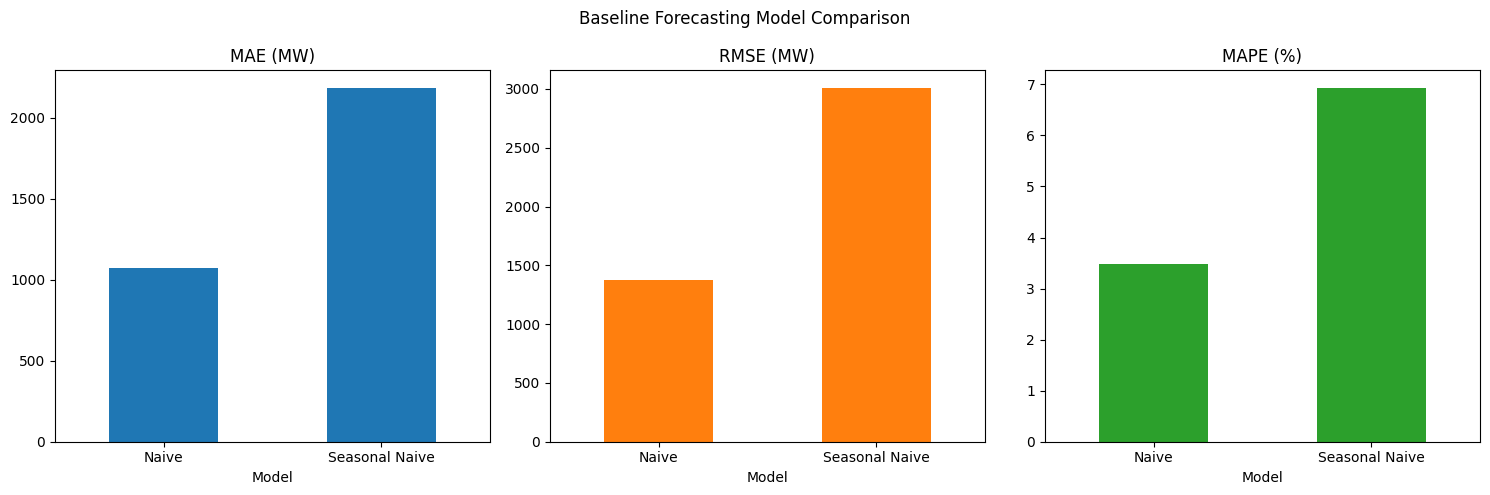

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": ["Naive", "Seasonal Naive"],
    "MAE (MW)": [mae, mae_seasonal],
    "RMSE (MW)": [rmse, rmse_seasonal],
    "MAPE (%)": [mape, mape_seasonal]
})

print(comparison.to_string(index=False))

comparison.set_index("Model").plot(
    kind="bar",
    subplots=True,
    layout=(1, 3),
    figsize=(15, 5),
    legend=False,
    rot=0
)

plt.suptitle("Baseline Forecasting Model Comparison")
plt.tight_layout()
plt.show()

In [64]:
# Compare both models using the same test rows

comparison_data = pd.DataFrame({
    "Actual": test.to_numpy(),
    "Naive": naive_predictions.to_numpy(),
    "Seasonal_Naive": seasonal_predictions.to_numpy()
}, index=test.index)

# Keep rows where all three values are available
comparison_data = comparison_data.dropna()

# Calculate metrics on the same observations
actual_common = comparison_data["Actual"]
naive_common = comparison_data["Naive"]
seasonal_common = comparison_data["Seasonal_Naive"]

comparison_fair = pd.DataFrame({
    "Model": ["Naive", "Seasonal Naive"],
    "MAE (MW)": [
        mean_absolute_error(actual_common, naive_common),
        mean_absolute_error(actual_common, seasonal_common)
    ],
    "RMSE (MW)": [
        np.sqrt(mean_squared_error(actual_common, naive_common)),
        np.sqrt(mean_squared_error(actual_common, seasonal_common))
    ],
    "MAPE (%)": [
        np.mean(np.abs(
            (actual_common - naive_common) / actual_common
        )) * 100,
        np.mean(np.abs(
            (actual_common - seasonal_common) / actual_common
        )) * 100
    ]
})

print("Common test observations:", len(comparison_data))
print(comparison_fair.round(2).to_string(index=False))

Common test observations: 29071
         Model  MAE (MW)  RMSE (MW)  MAPE (%)
         Naive   1069.85    1373.68      3.48
Seasonal Naive   2183.19    3007.94      6.93


**Baseline Forecasting Model Comparison**

Two baseline forecasting models, Naive and Seasonal Naive, were evaluated using the same 29,071 test observations.

The Naive Model achieved an MAE of 1,069.85 MW, an RMSE of 1,373.68 MW, and a MAPE of 3.48%. The Seasonal Naive Model achieved an MAE of 2,183.19 MW, an RMSE of 3,007.94 MW, and a MAPE of 6.93%.

Based on these results, the Naive Model performed better than the Seasonal Naive Model on this test set. However, further experiments with advanced forecasting models are required to determine whether prediction accuracy can be improved.


**Exponential Smoothing**

In [65]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

print("Simple Exponential Smoothing is ready.")

Simple Exponential Smoothing is ready.


In [66]:
# Step 2: Train the Simple Exponential Smoothing model

ses_model = SimpleExpSmoothing(
    train,
    initialization_method="estimated"
)

ses_fitted = ses_model.fit()

print("Simple Exponential Smoothing model trained successfully.")
print("Estimated smoothing level (alpha):", round(ses_fitted.params["smoothing_level"], 4))

C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Simple Exponential Smoothing model trained successfully.
Estimated smoothing level (alpha): 1.0


**Simple Exponential Smoothing Forecasting on Test Data**

In [67]:
# Step 3: Generate SES forecasts for the test period

ses_predictions = ses_fitted.forecast(steps=len(test))

# Match forecast index with test index for evaluation
ses_predictions.index = test.index

print("SES forecast generated successfully.")
print("Number of predictions:", len(ses_predictions))
print("\nFirst 5 SES predictions:")
print(ses_predictions.head())

SES forecast generated successfully.
Number of predictions: 29074

First 5 SES predictions:
Datetime
2015-04-09 15:00:00    32613.000003
2015-04-09 16:00:00    32613.000003
2015-04-09 17:00:00    32613.000003
2015-04-09 18:00:00    32613.000003
2015-04-09 19:00:00    32613.000003
dtype: float64


C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


**Evaluate SES Forecast Performance**

In [68]:
# Step 4: Evaluate SES Forecast Performance

valid_ses = ses_predictions.notna() & test.notna()

actual_ses = test.loc[valid_ses]
predicted_ses = ses_predictions.loc[valid_ses]

mae_ses = mean_absolute_error(actual_ses, predicted_ses)

rmse_ses = np.sqrt(
    mean_squared_error(actual_ses, predicted_ses)
)

mape_ses = np.mean(
    np.abs((actual_ses - predicted_ses) / actual_ses)
) * 100

print("SES Model Performance")
print("----------------------")
print(f"MAE:  {mae_ses:.2f} MW")
print(f"RMSE: {rmse_ses:.2f} MW")
print(f"MAPE: {mape_ses:.2f}%")

SES Model Performance
----------------------
MAE:  5423.97 MW
RMSE: 6665.56 MW
MAPE: 18.52%


**Naive vs SES comparison chart**

Model    MAE (MW)   RMSE (MW)  MAPE (%)
Naive 1069.850000 1373.680000  3.480000
  SES 5423.970593 6665.560707 18.520393


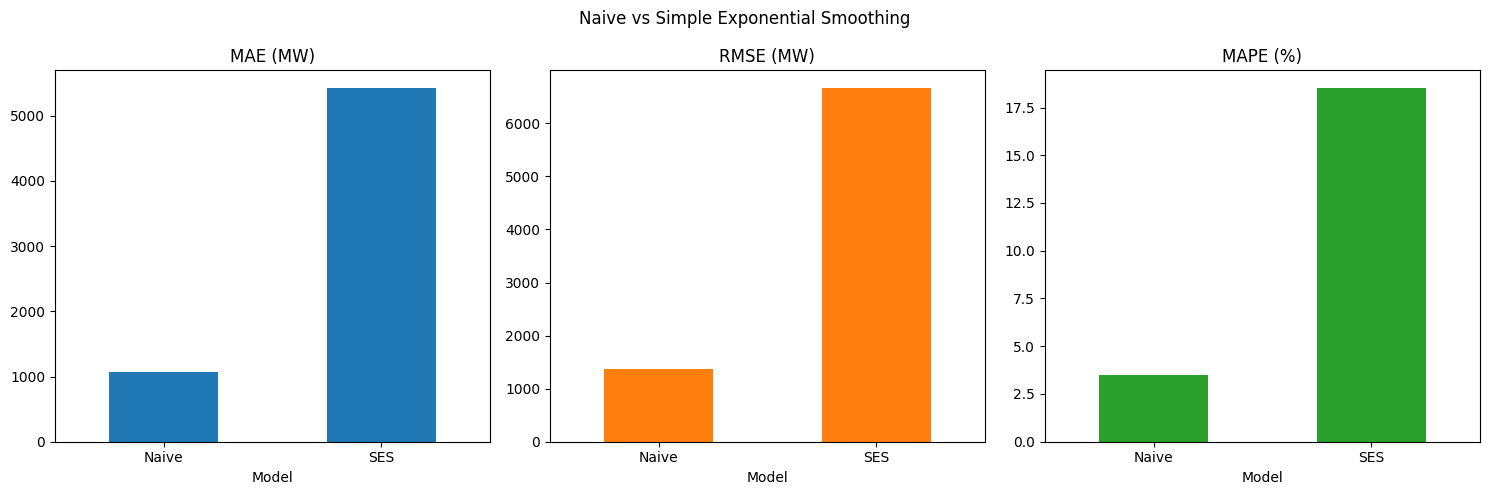

In [69]:
# Step 5: Compare Naive and SES Models

comparison_ses = pd.DataFrame({
    "Model": ["Naive", "SES"],
    "MAE (MW)": [1069.85, mae_ses],
    "RMSE (MW)": [1373.68, rmse_ses],
    "MAPE (%)": [3.48, mape_ses]
})

print(comparison_ses.to_string(index=False))

comparison_ses.set_index("Model").plot(
    kind="bar",
    subplots=True,
    layout=(1, 3),
    figsize=(15, 5),
    legend=False,
    rot=0
)

plt.suptitle("Naive vs Simple Exponential Smoothing")
plt.tight_layout()
plt.show()

**Holt-Winters Exponential Smoothing for Electricity Demand Forecasting**

In [70]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("Holt-Winters Exponential Smoothing is ready.")

Holt-Winters Exponential Smoothing is ready.


**Prepare Training Data for Holt-Winters Model**

In [71]:
# Step 7: Prepare training data for Holt-Winters

# Use the existing chronological training data
hw_train = train.copy()

print("Training observations:", len(hw_train))
print("Missing values:", hw_train.isna().sum())
print("Seasonal period: 24 observations (daily seasonality)")
print("Training data prepared successfully.")

Training observations: 116292
Missing values: 0
Seasonal period: 24 observations (daily seasonality)
Training data prepared successfully.


**Train the Holt-Winters Model**

In [72]:
# Step 8: Train the Holt-Winters Model

hw_model = ExponentialSmoothing(
    hw_train,
    trend="add",
    seasonal="add",
    seasonal_periods=24,
    initialization_method="estimated"
)

hw_fitted = hw_model.fit()

print("Holt-Winters model trained successfully.")
print("Training observations:", len(hw_train))
print("Estimated smoothing parameters:")
print(hw_fitted.params)

C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Holt-Winters model trained successfully.
Training observations: 116292
Estimated smoothing parameters:
{'smoothing_level': np.float64(0.794772342390093), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.20522765760990702), 'damping_trend': nan, 'initial_level': np.float64(30552.561963325632), 'initial_trend': np.float64(0.006377023323030797), 'initial_seasons': array([-4493.5134394 , -5397.07073106, -5720.58219558, -5759.29262462,
       -5233.18220177, -3508.8124101 ,  -198.25825929,  1975.02610065,
        2382.84276113,  2487.66046946,  2305.22401731,  1775.16882135,
         900.46363103,   298.69957619,  -336.17490043,  -427.62802543,
         979.46051624,  4565.03707216,  5088.73498882,  4637.05269716,
        3936.90113157,  2411.26728667,   -44.90406693, -2623.78843322]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


**Generate Holt-Winters Forecasts**

In [73]:
# Step 9: Generate Holt-Winters Forecasts

hw_predictions = hw_fitted.forecast(steps=len(test))

# Match forecast index with test data
hw_predictions.index = test.index

print("Holt-Winters forecast generated successfully.")
print("Number of predictions:", len(hw_predictions))

print("\nFirst 5 predictions:")
print(hw_predictions.head())

C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Holt-Winters forecast generated successfully.
Number of predictions: 29074

First 5 predictions:
Datetime
2015-04-09 15:00:00    31840.479774
2015-04-09 16:00:00    31413.650645
2015-04-09 17:00:00    31412.654912
2015-04-09 18:00:00    31668.628607
2015-04-09 19:00:00    31896.763772
dtype: float64


**Evaluate Holt-Winters Forecast Performance**

In [74]:
# Step 10: Evaluate Holt-Winters Model Performance

valid_hw = hw_predictions.notna() & test.notna()

actual_hw = test.loc[valid_hw]
predicted_hw = hw_predictions.loc[valid_hw]

mae_hw = mean_absolute_error(actual_hw, predicted_hw)

rmse_hw = np.sqrt(
    mean_squared_error(actual_hw, predicted_hw)
)

mape_hw = np.mean(
    np.abs((actual_hw - predicted_hw) / actual_hw)
) * 100

print("Holt-Winters Model Performance")
print("--------------------------------")
print(f"MAE:  {mae_hw:.2f} MW")
print(f"RMSE: {rmse_hw:.2f} MW")
print(f"MAPE: {mape_hw:.2f}%")

Holt-Winters Model Performance
--------------------------------
MAE:  4788.39 MW
RMSE: 6041.80 MW
MAPE: 15.66%


**Create a Model Comparison Table**

**Compare Naive, SES, and Holt-Winters Models**

In [75]:
# Step 11: Compare forecasting models

model_comparison = pd.DataFrame({
    "Model": ["Naive", "SES", "Holt-Winters"],
    "MAE (MW)": [1069.85, mae_ses, mae_hw],
    "RMSE (MW)": [1373.68, rmse_ses, rmse_hw],
    "MAPE (%)": [3.48, mape_ses, mape_hw]
})

print(model_comparison.round(2).to_string(index=False))

       Model  MAE (MW)  RMSE (MW)  MAPE (%)
       Naive   1069.85    1373.68      3.48
         SES   5423.97    6665.56     18.52
Holt-Winters   4788.39    6041.80     15.66


**Analyze Weekly Seasonality Using Lag-168**

In [76]:
# Step 12: Analyze Weekly Seasonality Using Lag-168

weekly_lag = ts.diff(168)

print("Weekly lag difference calculated.")
print("Number of observations:", len(weekly_lag))
print("Missing values:", weekly_lag.isna().sum())

print("\nFirst 5 weekly lag differences:")
print(weekly_lag.dropna().head())

Weekly lag difference calculated.
Number of observations: 145366
Missing values: 168

First 5 weekly lag differences:
Datetime
2002-01-08 01:00:00    -948.0
2002-01-08 02:00:00    -595.0
2002-01-08 03:00:00      18.0
2002-01-08 04:00:00     643.0
2002-01-08 05:00:00    1204.0
Name: PJME_MW, dtype: float64


**Visualize Weekly Lag Differences**

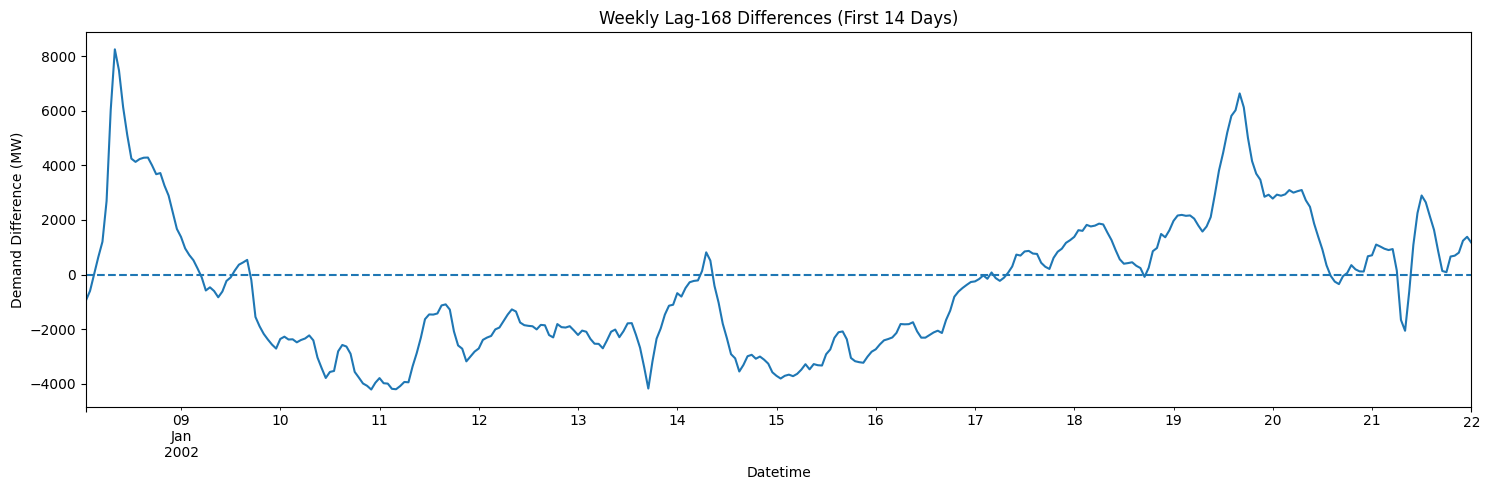

In [77]:
# Step 13: Visualize Weekly Seasonal Differences

plt.figure(figsize=(15, 5))

weekly_lag.dropna().iloc[:24 * 14].plot()

plt.title("Weekly Lag-168 Differences (First 14 Days)")
plt.xlabel("Datetime")
plt.ylabel("Demand Difference (MW)")
plt.axhline(y=0, linestyle="--")
plt.tight_layout()
plt.show()

Weekly seasonal differencing was performed using a lag of 168 observations to analyze week-over-week electricity demand changes.
Positive values indicate increased demand, while negative values indicate decreased demand compared with the previous week.
Remaining fluctuations may indicate additional temporal patterns that require further analysis.
ACF plots and stationarity tests will help determine the next steps for forecasting model development.


**ACF of Weekly Differenced Series**

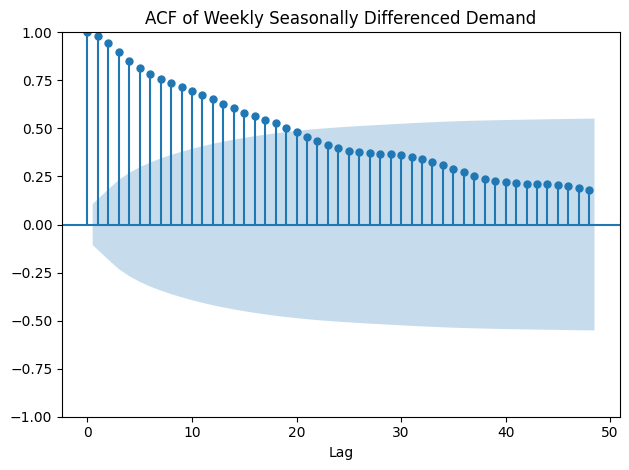

In [78]:
# Step 14: Analyze ACF after Weekly Seasonal Differencing

from statsmodels.graphics.tsaplots import plot_acf

weekly_diff_clean = weekly_lag.dropna()

plot_acf(weekly_diff_clean.iloc[:24 * 14], lags=48)

plt.title("ACF of Weekly Seasonally Differenced Demand")
plt.xlabel("Lag")
plt.tight_layout()
plt.show()

In [79]:
from statsmodels.tsa.stattools import adfuller

weekly_diff_clean = weekly_lag.dropna()

adf_result = adfuller(weekly_diff_clean)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

ADF Statistic: -31.341270155130122
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4303950611940985), '5%': np.float64(-2.8615599164100605), '10%': np.float64(-2.5667806007962626)}


**PACF Map**

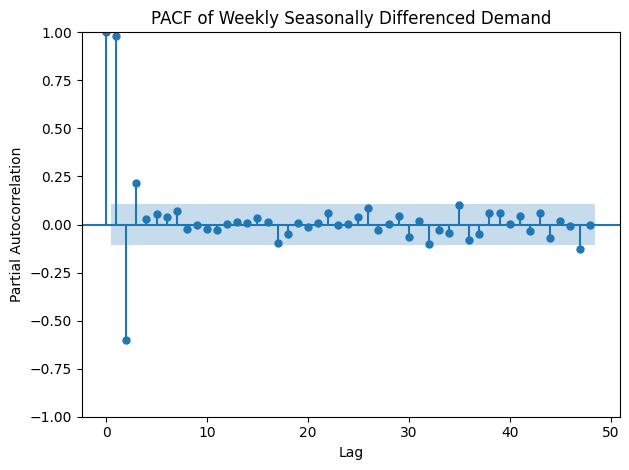

In [80]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

weekly_diff_clean = weekly_lag.dropna()

plot_pacf(
    weekly_diff_clean.iloc[:24 * 14],
    lags=48,
    method="ywm"
)

plt.title("PACF of Weekly Seasonally Differenced Demand")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

**6- Machine Learning — Random Forest**

**Short Machine Learning forecasting code**

In [81]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

data = dataset[["PJME_MW"]].copy()

for lag in [1, 24, 168]:
    data[f"lag_{lag}"] = data["PJME_MW"].shift(lag)

data["hour"] = data.index.hour
data["day"] = data.index.dayofweek
data = data.dropna()

split = int(len(data) * 0.8)
train, test = data.iloc[:split], data.iloc[split:]

X_train, y_train = train.drop(columns="PJME_MW"), train["PJME_MW"]
X_test, y_test = test.drop(columns="PJME_MW"), test["PJME_MW"]

model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, pred), 2), "MW")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 2), "MW")

MAE: 476.29 MW
RMSE: 643.31 MW


**Visualize actual vs predicted demand**

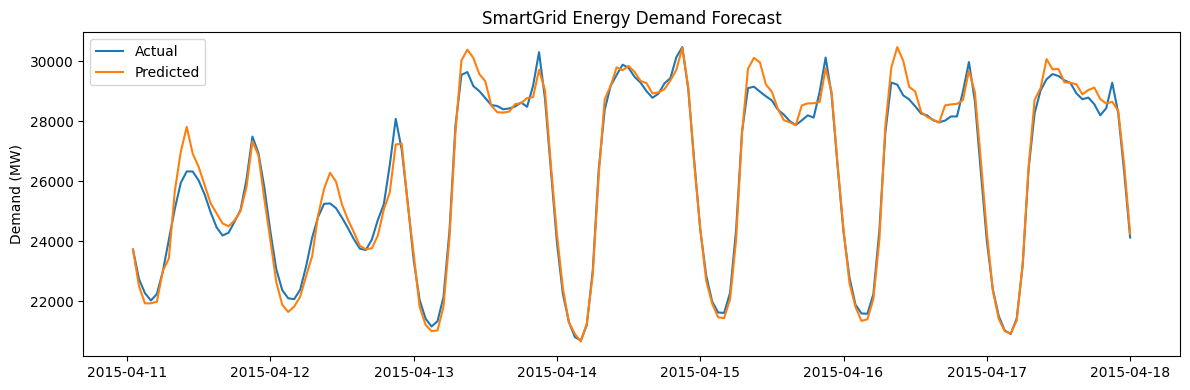

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y_test.index[:168], y_test.iloc[:168], label="Actual")
plt.plot(y_test.index[:168], pred[:168], label="Predicted")
plt.title("SmartGrid Energy Demand Forecast")
plt.ylabel("Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

**Peak Load Prediction**

In [83]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

print("Actual Peak Demand:")
print(results["Actual"].idxmax(), round(results["Actual"].max(), 2), "MW")

print("\nPredicted Peak Demand:")
print(results["Predicted"].idxmax(), round(results["Predicted"].max(), 2), "MW")

Actual Peak Demand:
2018-07-02 18:00:00 56609.0 MW

Predicted Peak Demand:
2016-07-25 17:00:00 56814.88 MW


"In the actual test data, the maximum electricity demand was 56,609 MW, recorded on July 2, 2018, at 6:00 PM.
The model's peak prediction was 56,814.88 MW, which occurred on July 25, 2016, at 5:00 PM."

**Final Model Evaluation**

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Model: Random Forest")
print("MAE:", round(mean_absolute_error(y_test, pred), 2), "MW")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 2), "MW")
print("Peak Demand Error:",
      round(abs(y_test.max() - pred.max()), 2), "MW")

Model: Random Forest
MAE: 476.29 MW
RMSE: 643.31 MW
Peak Demand Error: 205.88 MW


**Analysis step**

In [85]:
comparison = pd.DataFrame({
    "Model": ["Naive", "SES", "Holt-Winters", "Random Forest"],
    "MAE (MW)": [1069.85, 5423.97, 4788.39, 476.29],
    "RMSE (MW)": [1373.68, 6665.56, 6041.80, 643.31]
})

print(comparison.to_string(index=False))

        Model  MAE (MW)  RMSE (MW)
        Naive   1069.85    1373.68
          SES   5423.97    6665.56
 Holt-Winters   4788.39    6041.80
Random Forest    476.29     643.31


**Final Project Conclusion**

**SmartGrid Energy Demand Forecasting and Peak Load Prediction**

This project analyzes historical hourly electricity demand data to identify time-based patterns and forecast electricity consumption. Time series analysis, stationarity testing, baseline forecasting models, and Random Forest regression were used.

The Random Forest model achieved an MAE of **476.29 MW** and an RMSE of **643.31 MW** in the current evaluation. The project also includes actual-versus-predicted demand visualization and peak-load analysis.

**Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Statsmodels, Scikit-learn, Time Series Analysis, Random Forest.


**7-Deep Learning — LSTM**

**Prepare the data**---------- **Deep Leanrning**

In [87]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

ts = dataset["PJME_MW"].dropna().astype("float32")

split = int(len(ts) * 0.8)
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(ts.iloc[:split].to_numpy().reshape(-1, 1))
test_scaled = scaler.transform(ts.iloc[split:].to_numpy().reshape(-1, 1))

print("Train:", len(train_scaled))
print("Test:", len(test_scaled))

Train: 116292
Test: 29074


**Create LSTM sequences**

In [88]:
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test, y_test_lstm = create_sequences(
    np.vstack([train_scaled[-24:], test_scaled])
)

X_train = X_train.reshape(-1, 24, 1)
X_test = X_test.reshape(-1, 24, 1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (116268, 24, 1)
X_test: (29074, 24, 1)


**Build and train the LSTM model**

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(32, input_shape=(24, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0061 - val_loss: 0.0017
Epoch 2/5
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 3/5
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0011 - val_loss: 6.9352e-04
Epoch 4/5
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 8.9529e-04 - val_loss: 7.2342e-04
Epoch 5/5
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 6.1428e-04 - val_loss: 7.5434e-04


**8- MAE and RMSE Evaluation**

**LSTM prediction and evaluation**

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred_scaled = model.predict(X_test, verbose=0)

lstm_pred = scaler.inverse_transform(pred_scaled).ravel()
lstm_actual = scaler.inverse_transform(
    y_test_lstm.reshape(-1, 1)
).ravel()

print("LSTM MAE:", round(mean_absolute_error(lstm_actual, lstm_pred), 2), "MW")
print("LSTM RMSE:", round(np.sqrt(mean_squared_error(lstm_actual, lstm_pred)), 2), "MW")

LSTM MAE: 916.4 MW
LSTM RMSE: 1193.43 MW


**9- Actual vs LSTM prediction graph**

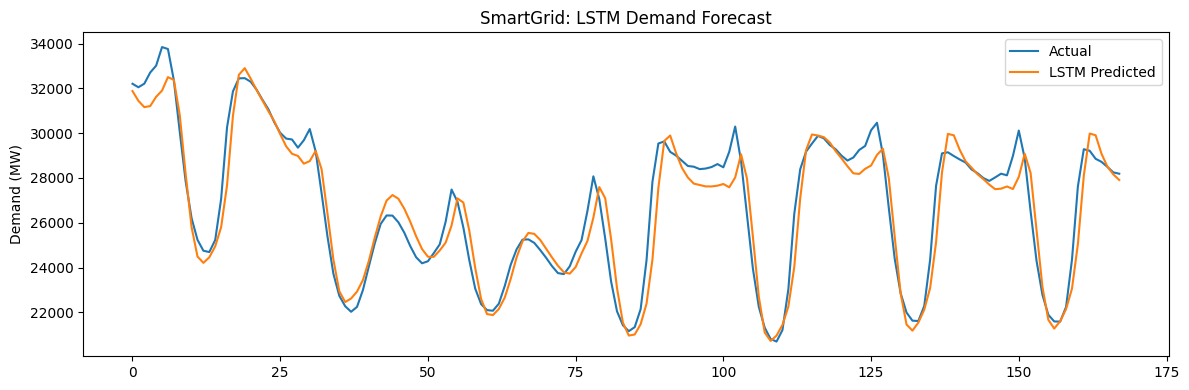

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(lstm_actual[:168], label="Actual")
plt.plot(lstm_pred[:168], label="LSTM Predicted")
plt.title("SmartGrid: LSTM Demand Forecast")
plt.ylabel("Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

**Final model comparison**

In [92]:
final_results = pd.DataFrame({
    "Model": ["Random Forest (ML)", "LSTM (DL)"],
    "MAE (MW)": [476.29, 916.40],
    "RMSE (MW)": [643.31, 1193.43]
})

print(final_results.to_string(index=False))

             Model  MAE (MW)  RMSE (MW)
Random Forest (ML)    476.29     643.31
         LSTM (DL)    916.40    1193.43


**All Models Comparison**

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": ["Naive", "SES", "Holt-Winters", "Random Forest", "LSTM"],
    "Type": ["Baseline", "TSA", "TSA", "Machine Learning", "Deep Learning"],
    "MAE (MW)": [1069.85, 5423.97, 4788.39, 476.29, 916.40],
    "RMSE (MW)": [1373.68, 6665.56, 6041.80, 643.31, 1193.43]
})

print(results.to_string(index=False))

        Model             Type  MAE (MW)  RMSE (MW)
        Naive         Baseline   1069.85    1373.68
          SES              TSA   5423.97    6665.56
 Holt-Winters              TSA   4788.39    6041.80
Random Forest Machine Learning    476.29     643.31
         LSTM    Deep Learning    916.40    1193.43


**Comparison Chart**

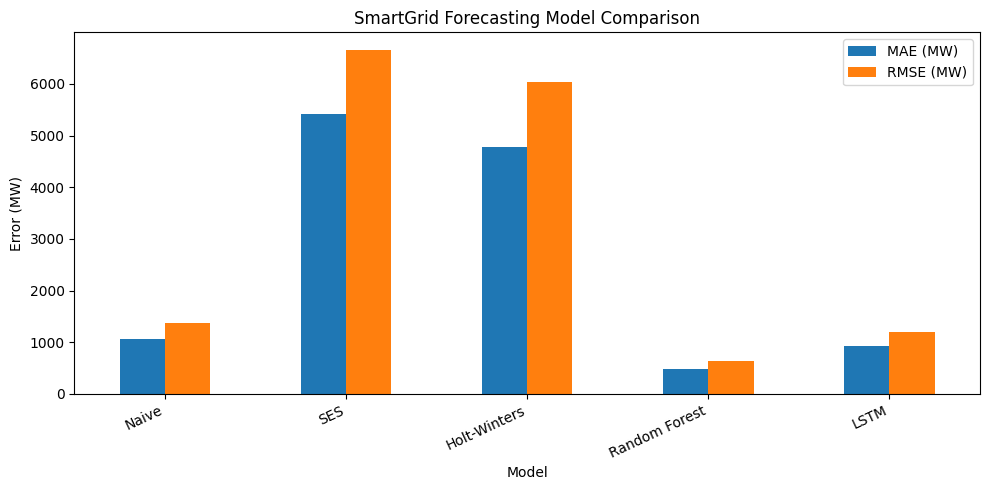

In [94]:
results.set_index("Model")[["MAE (MW)", "RMSE (MW)"]].plot(
    kind="bar", figsize=(10, 5)
)

plt.title("SmartGrid Forecasting Model Comparison")
plt.ylabel("Error (MW)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**10-Peak Load Analysis**

**Identify the lowest-error model**

In [95]:
print("Lowest MAE:", results.loc[results["MAE (MW)"].idxmin(), "Model"])
print("Lowest RMSE:", results.loc[results["RMSE (MW)"].idxmin(), "Model"])

Lowest MAE: Random Forest
Lowest RMSE: Random Forest


**Expected result: Random Forest has the lowest reported MAE (476.29 MW) and RMSE (643.31 MW).**

**Project conclusion**

**Lowest reported error**----- Random Forest.

**Deep Learning model**------- LSTM trained and evaluated.

**Time Series Analysis**------- ADF, ACF, PACF, decomposition and baseline forecasting completed.

**Peak-load analysis**--------- Actual and predicted maximum demand identified.

**Completed the topics for this project**

Data Loading & Cleaning

EDA and Visualization

Time Series Analysis (TSA)

ADF, ACF, PACF & Decomposition

Naive, SES & Holt-Winters

Machine Learning — Random Forest

Deep Learning — LSTM

MAE and RMSE Evaluation

Actual vs Predicted Graph

Peak Load Analysis